In [1]:
import pybamm
import numpy as np
import pandas as pd

# Porosity range
porosity_values = [round(p, 2) for p in np.arange(0.55, 0.71, 0.01)]

# Fixed values
total_volume_fraction = 1.0
cbd_frac = 0.05
total_am_fraction = total_volume_fraction - cbd_frac  # Active material = 0.95 - porosity
silicon_ratio = 0.10  # 10% silicon in active material

# Model setup
model = pybamm.lithium_ion.DFN({
    "particle phases": ("2", "1"),
    "open-circuit potential": (("single", "current sigmoid"), "single"),
})
param = pybamm.ParameterValues("Chen2020_composite")

# Define experiment (only discharge at 1C)
experiment = pybamm.Experiment([
    "Discharge at 1C until 2.5 V"
])

# Simulation loop
all_data = []

for eps in porosity_values:
    print(f"Simulating porosity = {eps}")
    try:
        active_material_frac = total_volume_fraction - cbd_frac - eps
        graphite_frac = (1 - silicon_ratio) * active_material_frac
        silicon_frac = silicon_ratio * active_material_frac

        # Update parameters
        param.update({
            "Primary: Negative electrode active material volume fraction": graphite_frac,
            "Secondary: Negative electrode active material volume fraction": silicon_frac,
            "Negative electrode porosity": eps,
        })

        sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment)
        solution = sim.solve()

        t = solution["Time [s]"].entries
        v = solution["Terminal voltage [V]"].entries
        neg_eta_primary = solution["X-averaged negative electrode primary reaction overpotential [V]"].entries
        neg_eta_secondary = solution["X-averaged negative electrode secondary reaction overpotential [V]"].entries
        elyte_eta = solution["X-averaged electrolyte overpotential [V]"].entries
        neg_ohmic = solution["X-averaged negative electrode ohmic losses [V]"].entries
        elyte_ohmic = solution["X-averaged electrolyte ohmic losses [V]"].entries

        neg_conc_primary = np.mean(
            solution["X-averaged negative primary particle concentration [mol.m-3]"](t), axis=0
        )
        neg_conc_secondary = np.mean(
            solution["X-averaged negative secondary particle concentration [mol.m-3]"](t), axis=0
        )

        # Interpolate to common time grid
        t_interp = np.linspace(0, t[-1], 500)
        data = {
            "time [s]": t_interp,
            "voltage [V]": np.interp(t_interp, t, v),
            "negative eta primary [V]": np.interp(t_interp, t, neg_eta_primary),
            "negative eta secondary [V]": np.interp(t_interp, t, neg_eta_secondary),
            "electrolyte overpotential [V]": np.interp(t_interp, t, elyte_eta),
            "ohmic negative electrode [V]": np.interp(t_interp, t, neg_ohmic),
            "ohmic electrolyte [V]": np.interp(t_interp, t, elyte_ohmic),
            "negative primary concentration [mol/m3]": np.interp(t_interp, t, neg_conc_primary),
            "negative secondary concentration [mol/m3]": np.interp(t_interp, t, neg_conc_secondary),
            "porosity": eps,
            "graphite_frac": graphite_frac,
            "silicon_frac": silicon_frac,
            "cbd_frac": cbd_frac,
            "total_active_material_frac": active_material_frac
        }

        df = pd.DataFrame(data)
        all_data.append(df)

    except Exception as e:
        print(f" Simulation failed for porosity={eps}: {e}")

# Save final dataset
if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    final_df.to_csv("composite_electrode_discharge_data.csv", index=False)
    print(" Dataset saved: composite_electrode_discharge_data.csv")
else:
    print(" No successful simulations.")


Simulating porosity = 0.55


At t = 301.627 and h = 2.74498e-18, the corrector convergence failed repeatedly or with |h| = hmin.


Simulating porosity = 0.56


At t = 212.845 and h = 1.36813e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 212.845 and h = 5.73997e-14, the corrector convergence failed repeatedly or with |h| = hmin.


Simulating porosity = 0.57


...

Simulating porosity = 0.69


At t = 138.466, repeated recoverable residual errors.
At t = 138.466, repeated recoverable residual errors.


Simulating porosity = 0.7


At t = 49.8792, repeated recoverable residual errors.
At t = 49.8792 and h = 2.10218e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 49.8792 and h = 3.31952e-20, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 49.8792 and h = 5.66701e-18, the corrector convergence failed repeatedly or with |h| = hmin.


 Dataset saved: composite_electrode_discharge_data.csv


In [3]:
final_df

,time [s],voltage [V],negative eta primary [V],negative eta secondary [V],electrolyte overpotential [V],ohmic negative electrode [V],ohmic electrolyte [V],negative primary concentration [mol/m3],negative secondary concentration [mol/m3],porosity,graphite_frac,silicon_frac,cbd_frac,total_active_material_frac
0,0.000000,3.983839,0.167047,0.148602,-0.012008,0.000006,-0.012008,27700.000000,276610.000000,0.55,0.360,0.040,0.05,0.40
1,6.869940,3.974520,0.164258,0.145716,-0.013934,0.000006,-0.011979,27633.262969,276522.891621,0.55,0.360,0.040,0.05,0.40
2,13.739881,3.965202,0.161470,0.142829,-0.015859,0.000007,-0.011950,27566.525937,276435.783241,0.55,0.360,0.040,0.05,0.40
3,20.609821,3.955884,0.158681,0.139942,-0.017785,0.000007,-0.011920,27499.788906,276348.674862,0.55,0.360,0.040,0.05,0.40
4,27.479762,3.946566,0.155893,0.137056,-0.019710,0.000007,-0.011891,27433.051875,276261.566482,0.55,0.360,0.040,0.05,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,2171.078919,2.559283,0.075097,0.240616,-0.028419,0.000006,-0.011181,79.347858,12343.979796,0.70,0.225,0.025,0.05,0.25
7996,2175.464937,2.544464,0.072632,0.244018,-0.028420,0.000006,-0.011182,76.823704,11327.506812,0.70,0.225,0.025,0.05,0.25
7997,2179.850955,2.529646,0.070168,0.247420,-0.028422,0.000006,-0.011182,74.299551,10311.033827,0.70,0.225,0.025,0.05,0.25
7998,2184.236973,2.514828,0.067703,0.250822,-0.028423,0.000006,-0.011183,71.775397,9294.560842,0.70,0.225,0.025,0.05,0.25


In [5]:
import pybamm
import numpy as np
import pandas as pd

# Porosity values from 0.55 to 0.70 
porosity_values = [round(p, 2) for p in np.arange(0.55, 0.71, 0.01)]

# Fixed electrode component assumptions
total_volume_fraction = 1.0
cbd_frac = 0.05
total_am_fraction = total_volume_fraction - cbd_frac  # = 0.95
silicon_ratio = 0.10  # 10% of active material is silicon

# Load DFN composite model and Chen2020 parameters
model = pybamm.lithium_ion.DFN({
    "particle phases": ("2", "1"),
    "open-circuit potential": (("single", "current sigmoid"), "single"),
})
param = pybamm.ParameterValues("Chen2020_composite")

# Discharge experiment
experiment = pybamm.Experiment(["Discharge at 1C until 2.5 V"])

# Store results
all_data = []

for eps in porosity_values:
    print(f"Simulating porosity = {eps}")
    try:
        active_material_frac = total_volume_fraction - cbd_frac - eps
        graphite_frac = (1 - silicon_ratio) * active_material_frac
        silicon_frac = silicon_ratio * active_material_frac

        # Update parameters
        param.update({
            "Primary: Negative electrode active material volume fraction": graphite_frac,
            "Secondary: Negative electrode active material volume fraction": silicon_frac,
            "Negative electrode porosity": eps,
        })

        sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment)
        solution = sim.solve()

        
        t = solution["Time [s]"].entries
        t_interp = np.linspace(0, t[-1], 500)

        data = {
            "time [s]": t_interp,
            "voltage [V]": np.interp(t_interp, t, solution["Terminal voltage [V]"].entries),
            "Negative reaction overpotential primary [V]": np.interp(t_interp, t, solution["X-averaged negative electrode primary reaction overpotential [V]"].entries),
            "Negative reaction overpotential secondary [V]": np.interp(t_interp, t, solution["X-averaged negative electrode secondary reaction overpotential [V]"].entries),
            "Electrolyte concentration overpotential [V]": np.interp(t_interp, t, solution["X-averaged electrolyte overpotential [V]"].entries),
            "Ohmic negative electrode overpotential [V]": np.interp(t_interp, t, solution["X-averaged negative electrode ohmic losses [V]"].entries),
            "Ohmic electrolyte overpotential [V]": np.interp(t_interp, t, solution["X-averaged electrolyte ohmic losses [V]"].entries),
            "Negative primary particle concentration [mol/m3]": np.interp(t_interp, t, np.mean(solution["X-averaged negative primary particle concentration [mol.m-3]"](t), axis=0)),
            "Negative secondary particle concentration [mol/m3]": np.interp(t_interp, t, np.mean(solution["X-averaged negative secondary particle concentration [mol.m-3]"](t), axis=0)),
            "porosity": eps,
            "graphite_frac": graphite_frac,
            "silicon_frac": silicon_frac,
            "cbd_frac": cbd_frac,
            "total_active_material_frac": active_material_frac
        }

        df = pd.DataFrame(data)
        all_data.append(df)

    except Exception as e:
        print(f"Simulation failed for porosity={eps}: {e}")

# Save final dataset
if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    final_df.to_csv("composite_electrode_discharge_data.csv", index=False)
    print("Dataset saved: composite_electrode_discharge_data.csv")
else:
    print(" No successful simulations.")


Simulating porosity = 0.55


At t = 301.627 and h = 2.74498e-18, the corrector convergence failed repeatedly or with |h| = hmin.


Simulating porosity = 0.56


At t = 212.845 and h = 1.36813e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 212.845 and h = 5.73997e-14, the corrector convergence failed repeatedly or with |h| = hmin.


Simulating porosity = 0.57


...

Simulating porosity = 0.69


At t = 138.466, repeated recoverable residual errors.
At t = 138.466, repeated recoverable residual errors.


Simulating porosity = 0.7


At t = 49.8792, repeated recoverable residual errors.
At t = 49.8792 and h = 2.10218e-14, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 49.8792 and h = 3.31952e-20, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 49.8792 and h = 5.66701e-18, the corrector convergence failed repeatedly or with |h| = hmin.


Dataset saved: composite_electrode_discharge_data.csv


In [7]:
final_df


,time [s],voltage [V],Negative reaction overpotential primary [V],Negative reaction overpotential secondary [V],Electrolyte concentration overpotential [V],Ohmic negative electrode overpotential [V],Ohmic electrolyte overpotential [V],Negative primary particle concentration [mol/m3],Negative secondary particle concentration [mol/m3],porosity,graphite_frac,silicon_frac,cbd_frac,total_active_material_frac
0,0.000000,3.983839,0.167047,0.148602,-0.012008,0.000006,-0.012008,27700.000000,276610.000000,0.55,0.360,0.040,0.05,0.40
1,6.869940,3.974520,0.164258,0.145716,-0.013934,0.000006,-0.011979,27633.262969,276522.891621,0.55,0.360,0.040,0.05,0.40
2,13.739881,3.965202,0.161470,0.142829,-0.015859,0.000007,-0.011950,27566.525937,276435.783241,0.55,0.360,0.040,0.05,0.40
3,20.609821,3.955884,0.158681,0.139942,-0.017785,0.000007,-0.011920,27499.788906,276348.674862,0.55,0.360,0.040,0.05,0.40
4,27.479762,3.946566,0.155893,0.137056,-0.019710,0.000007,-0.011891,27433.051875,276261.566482,0.55,0.360,0.040,0.05,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,2171.078919,2.559283,0.075097,0.240616,-0.028419,0.000006,-0.011181,79.347858,12343.979796,0.70,0.225,0.025,0.05,0.25
7996,2175.464937,2.544464,0.072632,0.244018,-0.028420,0.000006,-0.011182,76.823704,11327.506812,0.70,0.225,0.025,0.05,0.25
7997,2179.850955,2.529646,0.070168,0.247420,-0.028422,0.000006,-0.011182,74.299551,10311.033827,0.70,0.225,0.025,0.05,0.25
7998,2184.236973,2.514828,0.067703,0.250822,-0.028423,0.000006,-0.011183,71.775397,9294.560842,0.70,0.225,0.025,0.05,0.25


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


df = pd.read_csv("composite_electrode_discharge_data.csv")

feature_cols = [
    "Ohmic electrolyte overpotential [V]",
    "Ohmic negative electrode overpotential [V]",
    "Negative reaction overpotential primary [V]",
    "Negative reaction overpotential secondary [V]",
    "Electrolyte concentration overpotential [V]",
    "Negative primary particle concentration [mol/m3]",
    "Negative secondary particle concentration [mol/m3]",
    "voltage [V]" 
]
target_col = "porosity"

# Normalize features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_data = scaler_X.fit_transform(df[feature_cols].values)
y_data = scaler_y.fit_transform(df[[target_col]].values)

# sliding window sequence 
window_size = 20
stride = 1

X_seq = []
y_seq = []

for i in range(0, len(X_data) - window_size, stride):
    X_seq.append(X_data[i:i+window_size])      # Shape: (window_size, num_features)
    y_seq.append(y_data[i+window_size])        # Porosity at t+window_size

X_seq = np.array(X_seq)
y_seq = np.array(y_seq).reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42)

print(f"Created {X_seq.shape[0]} sequences of shape {X_seq.shape[1:]}")
print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")


Created 7980 sequences of shape (20, 8)
Training samples: 6384 | Test samples: 1596


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# SimpleRNN model
model_rnn = Sequential([
    SimpleRNN(128, return_sequences=True, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(64, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile
model_rnn.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Train
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1354 - mae: 0.2577 - val_loss: 0.0047 - val_mae: 0.0541
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0171 - mae: 0.1028 - val_loss: 0.0103 - val_mae: 0.0899
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0105 - mae: 0.0798 - val_loss: 0.0023 - val_mae: 0.0369
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0076 - mae: 0.0672 - val_loss: 0.0031 - val_mae: 0.0457
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0060 - mae: 0.0602 - val_loss: 0.0011 - val_mae: 0.0248
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0046 - mae: 0.0526 - val_loss: 0.0017 - val_mae: 0.0346
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - mae: 0.0524 - val_loss: 0.0015 - val_mae: 0.0310
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0038 - mae: 0.0478 - val_loss: 0.0011 - val_mae: 0.0264
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RMSE: 0.0034
MAE:  0.0024
R²:   0.9947


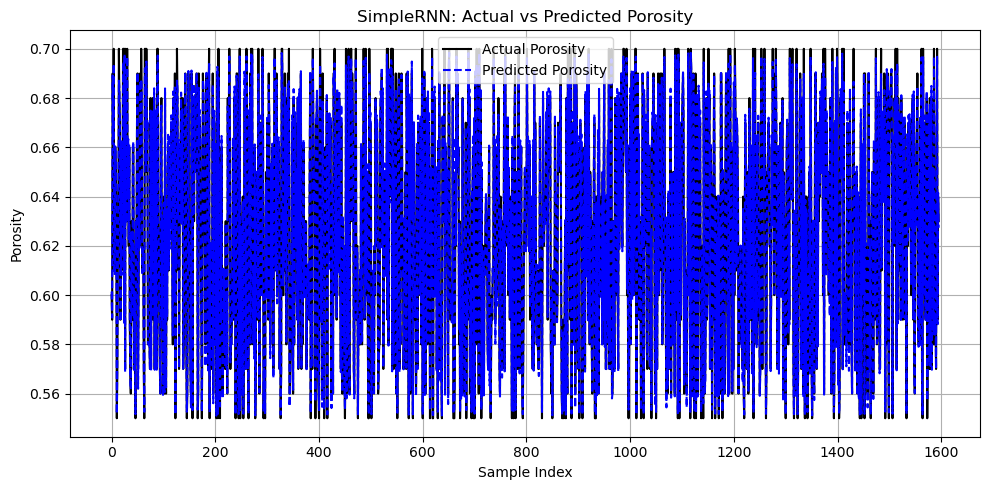

y_true[:5]: [0.6  0.59 0.69 0.66 0.7 ]
y_pred[:5]: [0.6014024  0.5908913  0.68917215 0.6633039  0.69388497]


In [12]:

y_pred_scaled = model_rnn.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)


# Metrics
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Plot (both true and predicted are now in original porosity scale)
plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Porosity", color="black")
plt.plot(y_pred, label="Predicted Porosity", linestyle="--", color="blue")
plt.title("SimpleRNN: Actual vs Predicted Porosity")
plt.xlabel("Sample Index")
plt.ylabel("Porosity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



print("y_true[:5]:", y_true[:5].flatten())
print("y_pred[:5]:", y_pred[:5].flatten())


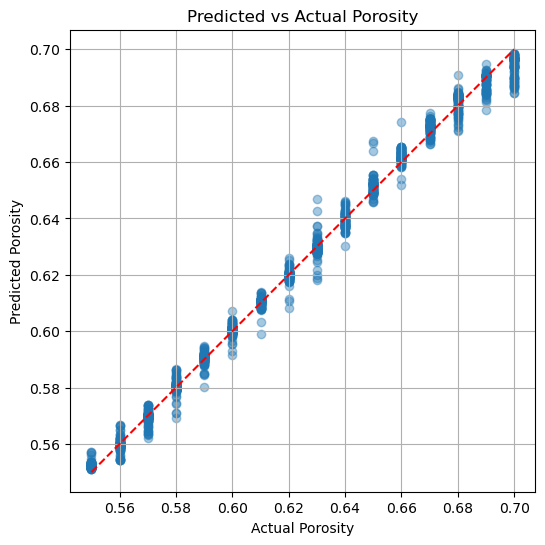

In [13]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.title("Predicted vs Actual Porosity")
plt.xlabel("Actual Porosity")
plt.ylabel("Predicted Porosity")
plt.grid(True)
plt.axis('equal')
plt.show()


In [14]:
from tensorflow.keras.layers import LSTM

# Build LSTM model
model_lstm = Sequential([
    LSTM(128, return_sequences=True, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile
model_lstm.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Train
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0391 - mae: 0.1238 - val_loss: 0.0036 - val_mae: 0.0459
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0047 - mae: 0.0505 - val_loss: 0.0033 - val_mae: 0.0473
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0035 - mae: 0.0431 - val_loss: 0.0015 - val_mae: 0.0270
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0025 - mae: 0.0373 - val_loss: 8.2417e-04 - val_mae: 0.0216
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0024 - mae: 0.0356 - val_loss: 0.0023 - val_mae: 0.0370
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0019 - mae: 0.0326 - val_loss: 7.2516e-04 - val_mae: 0.0186
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0015 - mae: 0.0282 - val_loss: 0.0076 - val_mae: 0.0696
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0020 - mae: 0.0328 - val_loss: 0.0014 - val_mae: 0.0292
Epoch 9/100
200/200 ━━━━━━━━━━━━

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 0.0040
MAE:  0.0031
R²:   0.9926


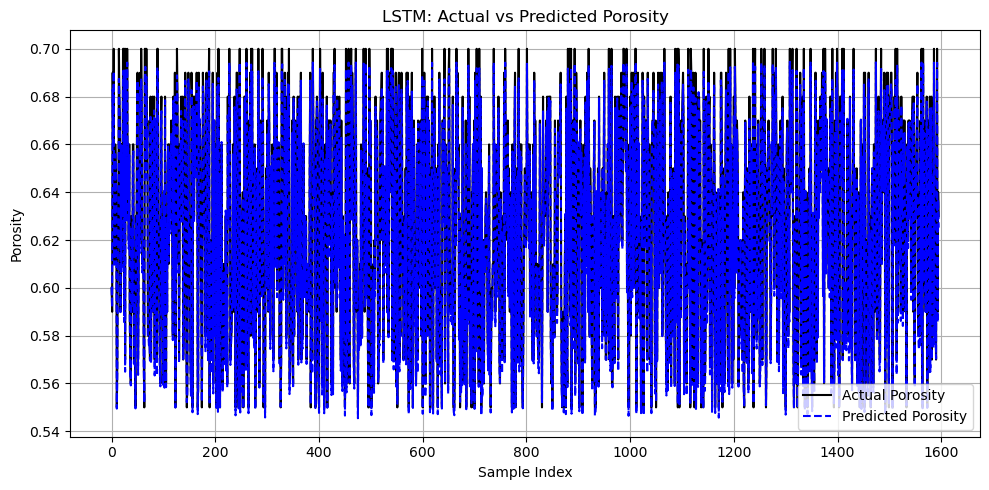

y_true[:5]: [0.6  0.59 0.69 0.66 0.7 ]
y_pred[:5]: [0.6000732  0.59178144 0.68296945 0.6605237  0.6905079 ]


In [15]:

y_pred_scaled = model_lstm.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)


# Metrics
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Plot (both true and predicted are now in original porosity scale)
plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Porosity", color="black")
plt.plot(y_pred, label="Predicted Porosity", linestyle="--", color="blue")
plt.title("LSTM: Actual vs Predicted Porosity")
plt.xlabel("Sample Index")
plt.ylabel("Porosity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



print("y_true[:5]:", y_true[:5].flatten())
print("y_pred[:5]:", y_pred[:5].flatten())


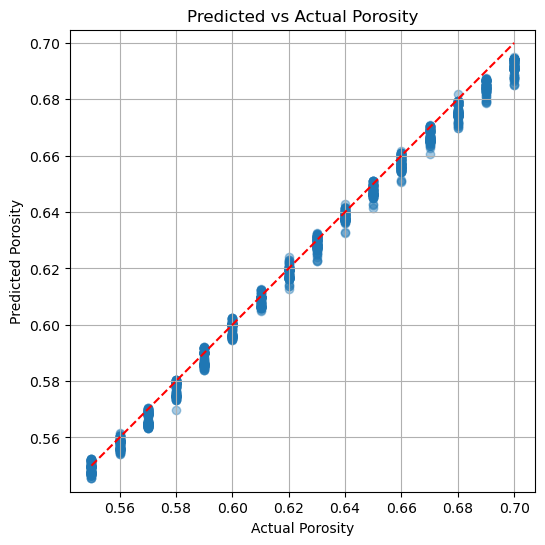

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.title("Predicted vs Actual Porosity")
plt.xlabel("Actual Porosity")
plt.ylabel("Predicted Porosity")
plt.grid(True)
plt.axis('equal')
plt.show()


In [17]:
from tensorflow.keras.layers import GRU


# Build GRU model
model_gru = Sequential([
    GRU(128, return_sequences=True, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(64, return_sequences=False, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile
model_gru.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

# Early stopping
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

# Train
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0434 - mae: 0.1404 - val_loss: 0.0057 - val_mae: 0.0613
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0047 - mae: 0.0508 - val_loss: 0.0015 - val_mae: 0.0277
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0035 - mae: 0.0433 - val_loss: 0.0030 - val_mae: 0.0392
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0028 - mae: 0.0390 - val_loss: 0.0019 - val_mae: 0.0332
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0022 - mae: 0.0346 - val_loss: 0.0020 - val_mae: 0.0308
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0021 - mae: 0.0341 - val_loss: 0.0022 - val_mae: 0.0364
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0018 - mae: 0.0317 - val_loss: 0.0011 - val_mae: 0.0241
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0018 - mae: 0.0318 - val_loss: 0.0027 - val_mae: 0.0386
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 0.0040
MAE:  0.0028
R²:   0.9924


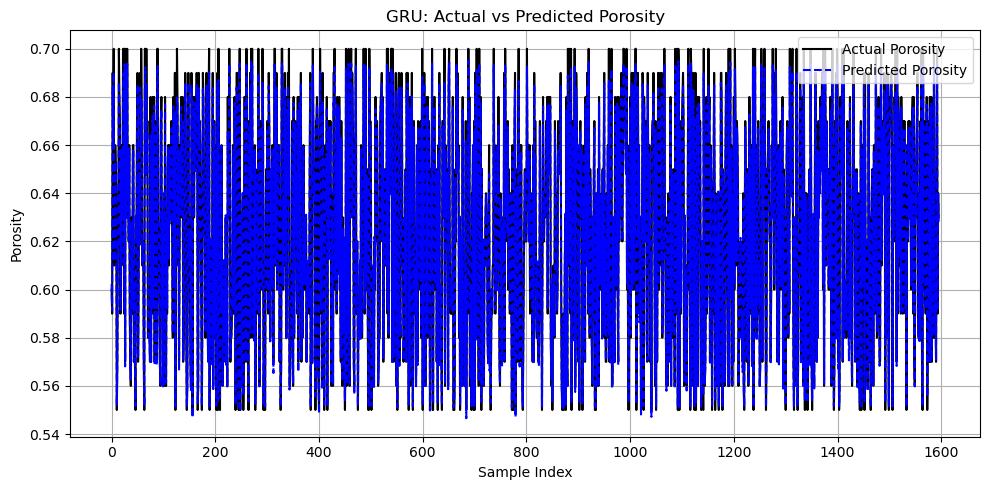

y_true[:5]: [0.6  0.59 0.69 0.66 0.7 ]
y_pred[:5]: [0.6023774  0.59126896 0.68389356 0.659229   0.6900681 ]


In [18]:

y_pred_scaled = model_gru.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)


# Metrics
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Plot (both true and predicted are now in original porosity scale)
plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Porosity", color="black")
plt.plot(y_pred, label="Predicted Porosity", linestyle="--", color="blue")
plt.title("GRU: Actual vs Predicted Porosity")
plt.xlabel("Sample Index")
plt.ylabel("Porosity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



print("y_true[:5]:", y_true[:5].flatten())
print("y_pred[:5]:", y_pred[:5].flatten())


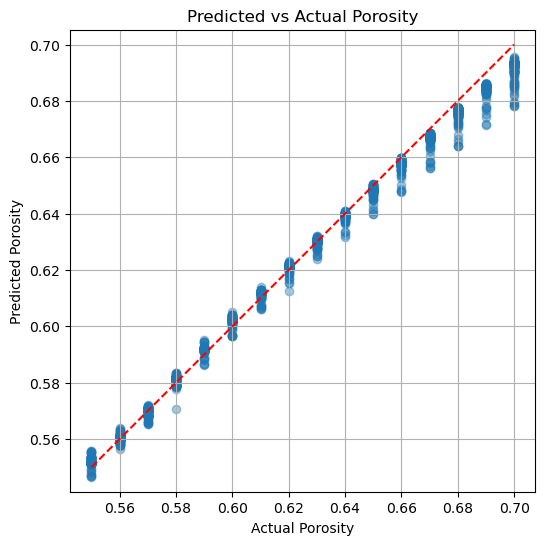

In [19]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.title("Predicted vs Actual Porosity")
plt.xlabel("Actual Porosity")
plt.ylabel("Predicted Porosity")
plt.grid(True)
plt.axis('equal')
plt.show()
